# Prediksi Churn Pelanggan - Sales & Marketing Dataset
## Ujian Akhir Semester | Bengkel Koding Data Science
### Aditya Ulil Albab - A11.2023.15093 - DS-03

---

## A. Latar Belakang

Churn pelanggan terjadi ketika pelanggan berhenti menggunakan layanan atau tidak lagi melakukan pembelian. Kondisi ini merugikan perusahaan karena biaya mendapatkan pelanggan baru jauh lebih besar dibanding mempertahankan yang sudah ada.

Dataset yang digunakan adalah **Sales and Marketing Customer Dataset** dari Kaggle yang berisi informasi demografis, perilaku penggunaan layanan, riwayat transaksi, hingga interaksi pelanggan dengan perusahaan. Dari data ini akan dibangun model machine learning untuk memprediksi pelanggan mana yang berpotensi churn.

---

## B. Deskripsi Dataset

| Kolom | Tipe | Keterangan |
|---|---|---|
| customer_id | int64 | ID unik pelanggan |
| gender | object | Jenis kelamin |
| age | float64 | Usia pelanggan |
| country | object | Negara asal |
| city | object | Kota pelanggan |
| signup_date | object | Tanggal mendaftar |
| last_purchase_date | object | Tanggal transaksi terakhir |
| acquisition_channel | object | Sumber akuisisi pelanggan |
| device_type | object | Jenis perangkat |
| subscription_type | object | Jenis langganan |
| is_premium_user | int64 | Status premium (0/1) |
| total_visits | int64 | Total kunjungan |
| avg_session_time | float64 | Rata-rata durasi sesi |
| pages_per_session | float64 | Rata-rata halaman per sesi |
| email_open_rate | float64 | Tingkat buka email |
| email_click_rate | float64 | Tingkat klik email |
| total_spent | float64 | Total pengeluaran |
| avg_order_value | float64 | Rata-rata nilai transaksi |
| discount_used | int64 | Penggunaan diskon (0/1) |
| coupon_code | object | Kode kupon |
| support_tickets | int64 | Jumlah tiket support |
| refund_requested | int64 | Permintaan refund (0/1) |
| delivery_delay_days | int64 | Keterlambatan pengiriman |
| payment_method | object | Metode pembayaran |
| satisfaction_score | float64 | Skor kepuasan pelanggan |
| nps_score | int64 | Net Promoter Score |
| marketing_spend_per_user | float64 | Biaya marketing per pelanggan |
| lifetime_value | float64 | Nilai total pelanggan |
| last_3_month_purchase_freq | int64 | Frekuensi beli 3 bulan terakhir |
| churn | int64 | **Target**: status churn (0/1) |

---

## C. Tujuan Proyek

1. Melakukan eksplorasi data (EDA) untuk memahami struktur data, distribusi variabel, dan korelasi antar fitur.
2. Membangun tiga kategori model machine learning: konvensional, ensemble bagging, dan ensemble voting.
3. Mengevaluasi performa model melalui tiga skenario: direct, preprocessing, dan hyperparameter tuning.
4. Menghasilkan total 9 model dan memilih model terbaik berdasarkan metrik klasifikasi.
5. Melakukan deployment model terbaik ke Streamlit Cloud.

---

## D. Exploratory Data Analysis (EDA)

### D.1 Import Library dan Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Jumlah baris  : 15,000
Jumlah kolom  : 30


### D.2 Lima Baris Pertama Dataset

In [3]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### D.3 Informasi Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

### D.4 Statistik Deskriptif

In [5]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


### D.5 Analisis Missing Value

In [6]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print('Kolom dengan missing value:')
print(missing_pct.to_string())

Kolom dengan missing value:
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000


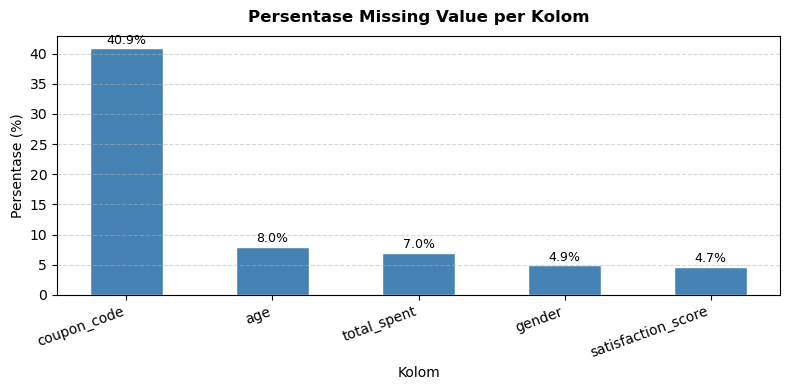

In [7]:
plt.figure(figsize=(8, 4))

plt.bar(missing_pct.index, missing_pct.values,
        color='steelblue', edgecolor='white', width=0.5)

plt.title('Persentase Missing Value per Kolom', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(missing_pct.values):
    plt.text(i, val + 0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:**  
Ada 5 kolom yang memiliki missing value. `coupon_code` paling banyak hilang (40.9%) karena memang tidak semua pelanggan memakai kupon, bukan berarti data rusak. Sementara `age`, `gender`, dan `satisfaction_score` yang hilang perlu ditangani di tahap preprocessing karena ketiganya relevan sebagai fitur model.

### D.6 Distribusi Variabel Target (Churn)

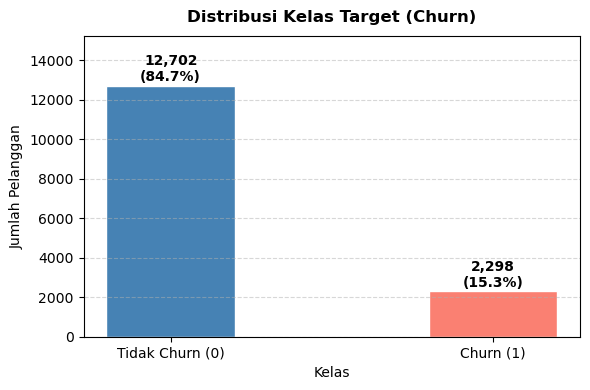

Tidak Churn (0) : 12,702 (84.7%)
Churn (1)       : 2,298 (15.3%)


In [8]:
churn_counts = df['churn'].value_counts()
labels = ['Tidak Churn (0)', 'Churn (1)']

plt.figure(figsize=(6, 4))

bars = plt.bar(labels, churn_counts.values,
               color=['steelblue', 'salmon'],
               edgecolor='white', width=0.4)

plt.title('Distribusi Kelas Target (Churn)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Pelanggan')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, churn_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 80,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print(f'Tidak Churn (0) : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)')
print(f'Churn (1)       : {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)')

**Insight:**  
Dataset tidak seimbang. Pelanggan yang tidak churn jauh lebih banyak (84.7%) dibanding yang churn (15.3%), dengan rasio sekitar 5.5:1. Kondisi ini perlu diperhatikan saat pemodelan karena model bisa saja condong memprediksi kelas mayoritas. Teknik seperti `class_weight='balanced'` atau resampling bisa menjadi solusi.

### D.7 Heatmap Korelasi Fitur Numerik

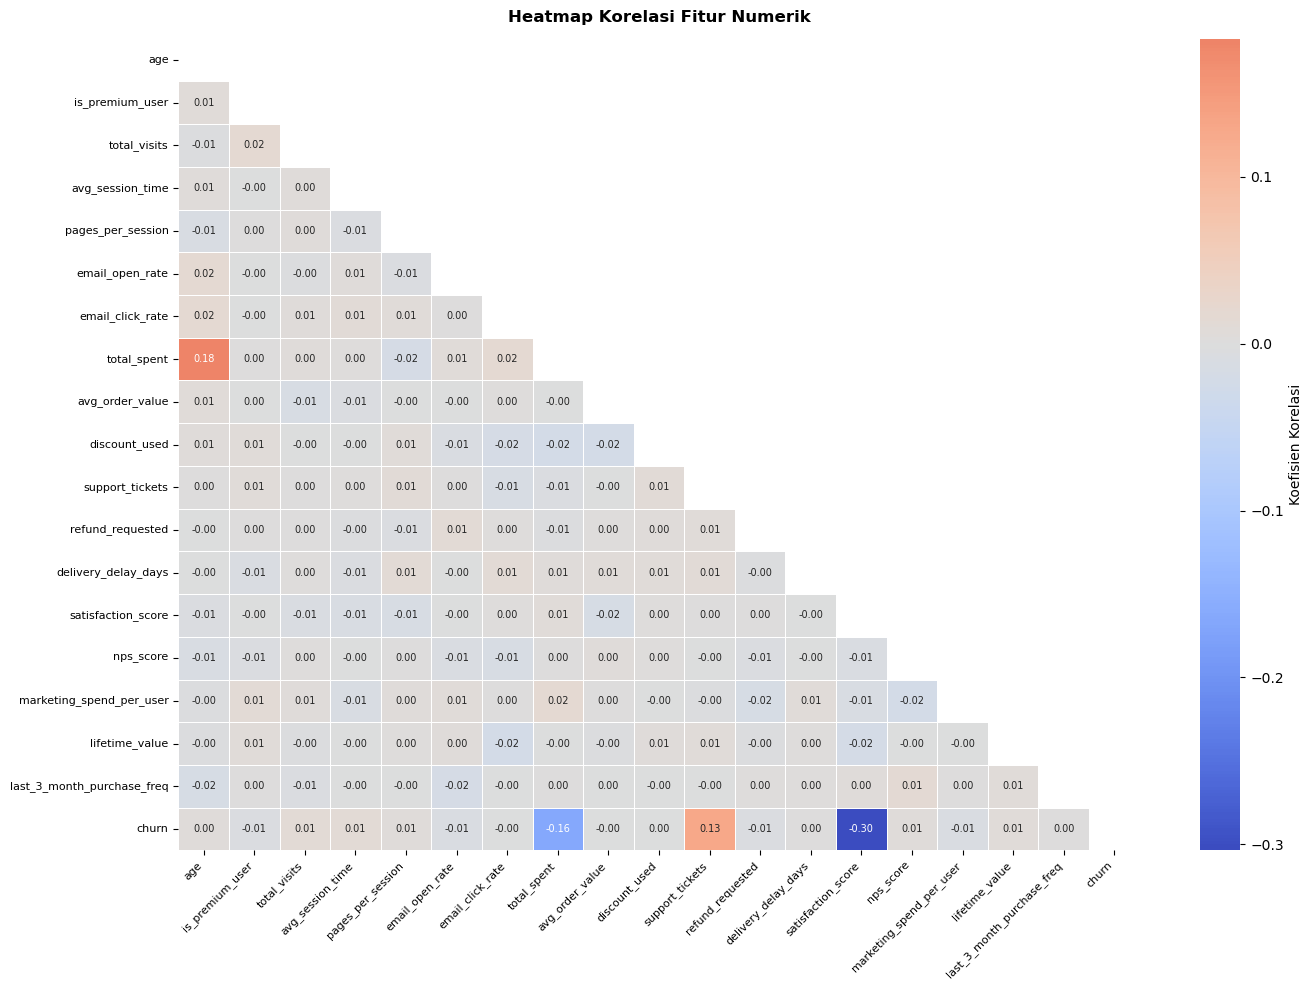

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'customer_id']

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Koefisien Korelasi'}
)

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
corr_churn = corr['churn'].drop('churn').sort_values(ascending=False)
print('Korelasi fitur terhadap Churn:')
print(corr_churn.to_string())

**Insight:**  
Secara umum tidak ada fitur yang berkorelasi tinggi terhadap `churn`, yang menunjukkan bahwa churn dipengaruhi oleh kombinasi banyak faktor, bukan satu variabel saja. `satisfaction_score` dan `nps_score` memiliki korelasi negatif terhadap churn, artinya semakin puas pelanggan semakin kecil kemungkinan churn. Sebaliknya, `support_tickets` dan `delivery_delay_days` berkorelasi positif, pelanggan yang sering komplain atau mengalami keterlambatan lebih rentan churn.

# E.Direct Model

### E.1 Import Library

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### E.2 Penentuan Fitur dan Target

In [5]:
df_numeric = df.select_dtypes(include=[np.number]).dropna()
X = df_numeric.drop(columns=['churn', 'customer_id'], errors='ignore')
y = df_numeric['churn']

### E.3 Splitting Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### E.4 Inisiasi Model

In [7]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(random_state=42)

model_knn = KNeighborsClassifier()
model_nb = GaussianNB()
model_voting = VotingClassifier(
    estimators=[('lr', model_lr), ('knn', model_knn), ('nb', model_nb)],
    voting='soft'
)

models = {
    'Logistic Regression (Konvensional)': model_lr,
    'Random Forest (Ensemble Bagging)': model_rf,
    'Voting Classifier (Ensemble Voting)': model_voting
}

### E.5 Pelatihan,Prediksi, dan Evaluasi

=== Logistic Regression (Konvensional) ===
Accuracy  : 0.8449
Precision : 0.5385
Recall    : 0.1620
F1-Score  : 0.2490



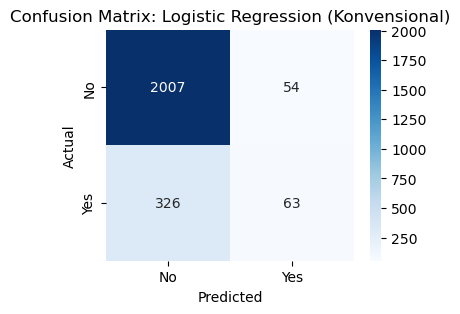

=== Random Forest (Ensemble Bagging) ===
Accuracy  : 0.8351
Precision : 0.4776
Recall    : 0.4113
F1-Score  : 0.4420



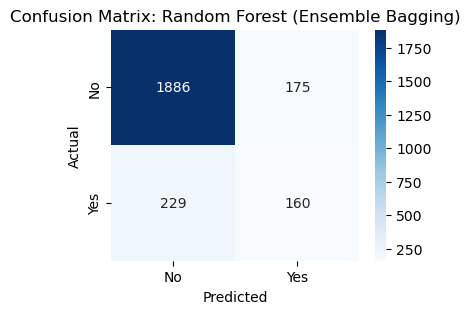

=== Voting Classifier (Ensemble Voting) ===
Accuracy  : 0.8404
Precision : 0.4872
Recall    : 0.0977
F1-Score  : 0.1627



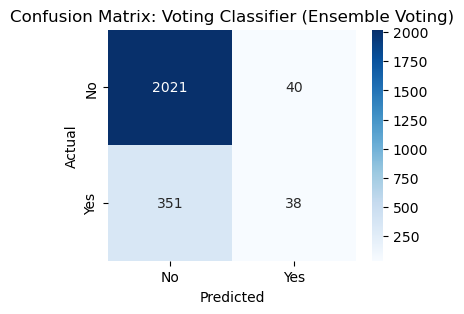

In [8]:
for name, model in models.items():
    print(f"=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}\n")
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Insight:

Meskipun akurasi tinggi (~84%), semua model gagal mendeteksi *churn* dengan baik dilihat dari recall rendah karena data langsung dilatih tanpa preprocessing jadi imbalanced data. Random Forest menjadi model terbaik dengan F1-Score tertinggi (0.4420) dibandingkan Logistic Regression (0.2490) dan Voting Classifier (0.1627).